# Runnables

chains are made using runnablesA

### Why

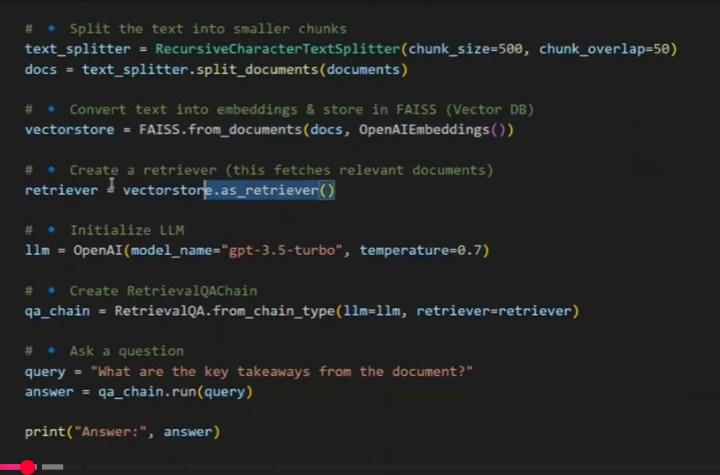

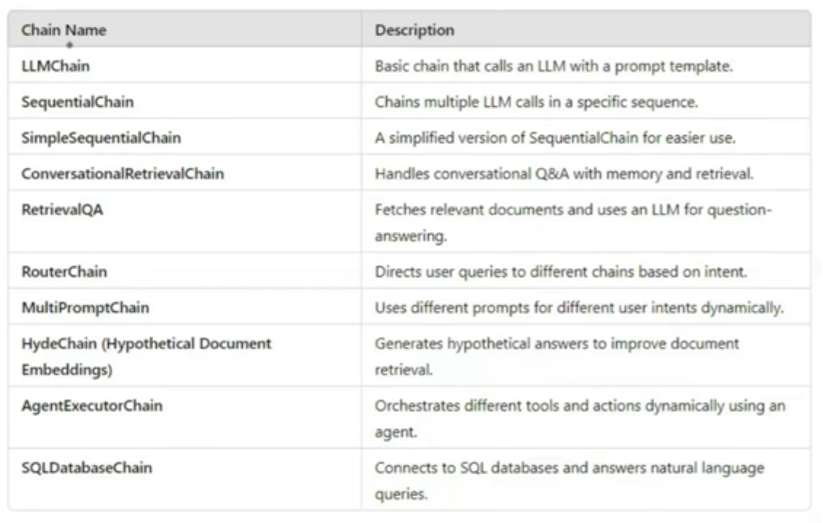

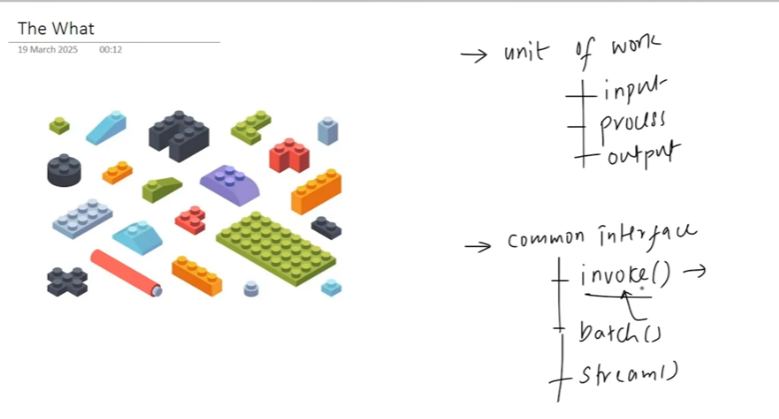

https://notebooklm.google.com/notebook/408a3486-10d8-4bc9-a4f2-a2321277741e

### Below the code is before runnables

In [1]:
import random


class NakliLLM:
    def __init__(self):
        print('LLM created')
    def predict(self, prompt):
        
        response_lst = [
            'Delhi is a ccapital of India.',
            'The weather is very good today.',
            'I am feeling sad today.',
            'The movie was fantastic.'
        ]
        return {'response' : random.choice(response_lst)}

In [2]:
llm = NakliLLM()
llm.predict("What is the capital of India?")

LLM created


{'response': 'The weather is very good today.'}

In [3]:
class nakliPromptTemplate:
    def __init__(self, template, input_variables):
        self.template = template
        self.input_variables = input_variables

    def format(self, input_dict):
        return self.template.format(**input_dict)

In [4]:
template = nakliPromptTemplate(
    template = "write a poem about {topic} of length {length}",
    input_variables = ['topic', 'length']
)
print(template.format({'topic': 'nature', 'length': '4 lines'}))


write a poem about nature of length 4 lines


In [7]:
prompt = template.format({'topic': 'nature', 'length': '4 lines'})
llm = NakliLLM()
response = llm.predict(prompt)
response

LLM created


{'response': 'I am feeling sad today.'}

In [8]:
# Now well connect these componenets
class NakliLLMchain:
    def __init__(self, llm, prompt):
        self.llm = llm 
        self.prompt = prompt
    
    def run(self, input_dict):
        formatted_prompt = self.prompt.format(input_dict)
        response = self.llm.predict(formatted_prompt)
        return response['response']

In [9]:
template = nakliPromptTemplate(
    template = "write a poem about {topic} of length {length}",
    input_variables = ['topic', 'length']
)

llm = NakliLLM()

chain = NakliLLMchain(llm, template)

response = chain.run({'topic': 'nature', 'length': '4 lines'})
print(response)

LLM created
The weather is very good today.


### Now we'll write demo code for the runnables


In [11]:
from abc import ABC, abstractmethod

class Runnable(ABC):
    @abstractmethod
    def invoke(self, input_data):
        pass
    
class NakliLLM(Runnable):
    def __init__(self):
        print('LLM created')
        
    def invoke(self, prompt):
        
        response_lst = [
            'Delhi is a ccapital of India.',
            'The weather is very good today.',
            'I am feeling sad today.',
            'The movie was fantastic.'
        ]
        return {'response' : random.choice(response_lst)}
    
    def predict(self, prompt):
        
        response_lst = [
            'Delhi is a ccapital of India.',
            'The weather is very good today.',
            'I am feeling sad today.',
            'The movie was fantastic.'
        ]
        return {'response' : random.choice(response_lst)}

class nakliPromptTemplate(Runnable):
    def __init__(self, template, input_variables):
        self.template = template
        self.input_variables = input_variables

    def invoke(self, input_dict):
        return self.template.format(**input_dict)
    def format(self, input_dict):
        return self.template.format(**input_dict)

In [12]:
class RunnableConnector(Runnable):
    def __init__(self, runnable_list):
        self.runnable_list = runnable_list
        
    def invoke(self, input_data):
        for runnable in self.runnable_list:
            input_data = runnable.invoke(input_data)
        return input_data
    
chain = RunnableConnector([prompt, llm])

template = nakliPromptTemplate(
    template = "write a poem about {topic} of length {length}",
    input_variables = ['topic', 'length']
)

llm = NakliLLM()
chain = RunnableConnector([template, llm])

LLM created


In [13]:
chain.invoke({'topic': 'nature', 'length': '4 lines'})

{'response': 'Delhi is a ccapital of India.'}

## This is how the runnables is implemented, as shown above

# Types of Runnables

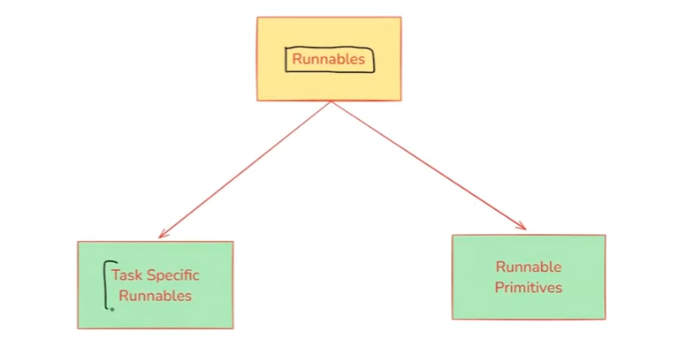

## 1. Task Specific Runnables

- Definition : These are core Langchain components that have been converted into runnables so they can be used in pipelines

- Purpose : Perform task specific operations like LLM calls, prompting, retrieval etc

- Example : 
1. ChatOpenAI - Runs as LLM model
2. PropmtTemplate - Formats prompt dynamically
3. Retriever -Retreives relevant documents

## 2. Runnable Primitives

- Definition : These are fundamental building blocks for structuring execution logic in AI workflows

- Purpose : They help orchestrate execution by defining how differenet runnables interact(sequentially, parallaly, conditionally) etc

- Example : RunnableSequence, RunnableParallel, RunnableBranch, etc

### 1. RunnableSequence


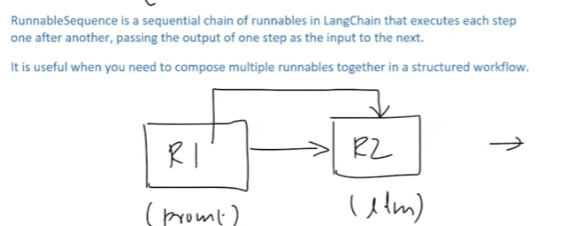

In [16]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnableBranch,RunnableLambda

load_dotenv()

prompt1 = PromptTemplate(
    template = "write a joke about {topic}",
    input_variables = ['topic']
)

prompt2 = PromptTemplate(
    template = "EXplain the joke about {text}",
    input_variables = ['text']
)

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

parser = StrOutputParser()

chain = RunnableSequence(prompt1, model, parser, prompt2, model, parser)

result = chain.invoke({'topic': 'programming'})
print(result)


The joke is a play on words. 'Bugs' has a double meaning here. 

In the context of programming, 'bugs' refers to errors or glitches in the code that need to be debugged (corrected). 

However, the phrase 'light attracts bugs' is also a common saying in insect biology, meaning that insects, such as flies and moths, are attracted to light sources.

So, the joke says that programmers prefer dark mode because light, in a literal sense, attracts insects (bugs). But, in a programming sense, it can also be interpreted as 'light attracts code bugs'. This wordplay creates a clever pun that connects two seemingly unrelated concepts.


### 2. RunnableParallel

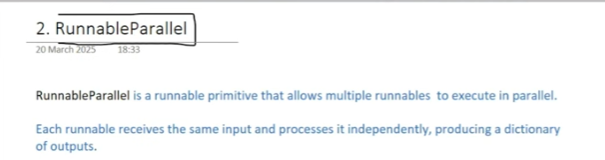

In [17]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence

load_dotenv()


hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

prompt1 = PromptTemplate(
    template = "Generate a tweet about {topic}",
    input_variables = ['topic']
)

prompt2 = PromptTemplate(
    template = "Generate a LinkedIn post about {topic}",
    input_variables = ['topic']
)

parser = StrOutputParser()

parallelChain = RunnableParallel({
    'tweet': RunnableSequence(prompt1, model, parser),
    'linkedin': RunnableSequence(prompt2, model, parser)
})

result = parallelChain.invoke({'topic': 'Artificial Intelligence'})
print(result)

{'tweet': '"The future is here! Artificial Intelligence is revolutionizing the way we live, work, and interact with technology. From personalized recommendations to life-saving medical breakthroughs, AI is transforming the world one innovation at a time #ArtificialIntelligence #AI"', 'linkedin': "**Revolutionizing Industries with Artificial Intelligence**\n\nAs AI continues to transform the way we live and work, it's essential to stay ahead of the curve. From enhanced customer experiences to improved operational efficiency, AI is revolutionizing industries across the globe.\n\nAt [Your Company/Organization], we're harnessing the power of AI to drive innovative solutions and stay competitive in today's fast-paced market. Some of the key benefits we've seen so far include:\n\n **Improved Decision Making**: AI-powered analytics enable data-driven decisions, reducing the risk of human error and increasing the accuracy of outcomes.\n\n **Increased Productivity**: Automation and AI-driven wo

### 3. RunnablePassthrough

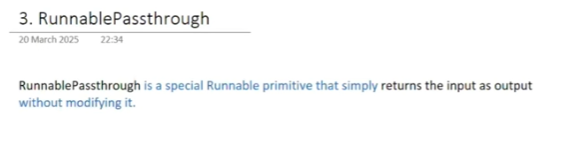

- Where is it used : like in the prev example where we generated the joke and its explanation, and at end we printed only the explanation, we can use this runnable and print both of them 

In [18]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnablePassthrough

load_dotenv()


hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

passthrough = RunnablePassthrough()

prompt1 = PromptTemplate(
    template = "write a joke about {topic}",
    input_variables = ['topic']
)

prompt2 = PromptTemplate(
    template = "EXplain the joke about {text}",
    input_variables = ['text']
)
parser = StrOutputParser()

jokeGenChain = RunnableSequence(prompt1, model, parser)

parallelChain = RunnableParallel({
    'joke': RunnablePassthrough(),
    'explanation': RunnableSequence(prompt2, model, parser)
})

finalChain = RunnableSequence(jokeGenChain, parallelChain)


result = finalChain.invoke({'topic': 'programming'})
print(result)


{'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'The joke is a play on words, leveraging the double meaning of "bugs." \n\nIn the context of coding and programming, a "bug" refers to a defect or error in software or a program that needs to be fixed. \n\nHowever, in a literal sense, "bugs" can also refer to insects. The joke is saying that programmers prefer dark mode (a darker color scheme on screens) because light attracts bugs, implying that light attracts insects, but also referencing the coding meaning of "bugs" in a clever and humorous way.'}


### 4. RunnableLambda

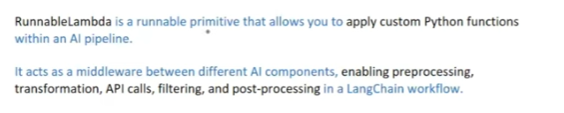

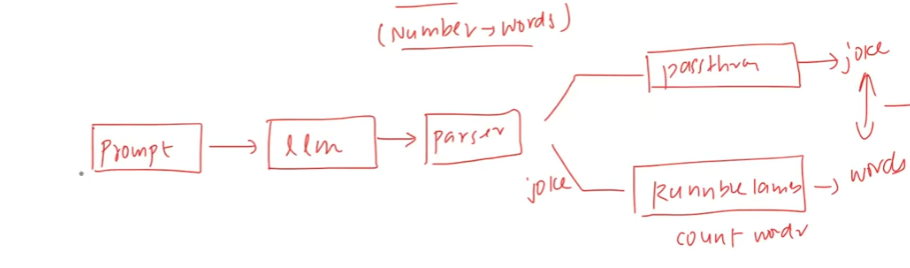

In [19]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnableLambda

load_dotenv()


hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

def word_count(text):
    return len(text.split())

RunnableWordCount = RunnableLambda(word_count)

print(RunnableWordCount.invoke("Hello world, this is a test."))


6


In [20]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnableLambda

load_dotenv()


hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

prompt1 = PromptTemplate(
    template = "write a joke about {topic}",
    input_variables = ['topic']
)

parser = StrOutputParser()

jokeGenchain = RunnableSequence(prompt1, model, parser)


parallelChain = RunnableParallel({
    'joke': RunnablePassthrough(),
    'word_count': RunnableLambda(word_count)
})

# U can write lambda function directly without defining it separately as well

finalChain = RunnableSequence(jokeGenchain, parallelChain)

result = finalChain.invoke({'topic': 'programming'})
print(result)

{'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'word_count': 10}


## 5. RunnableBranch

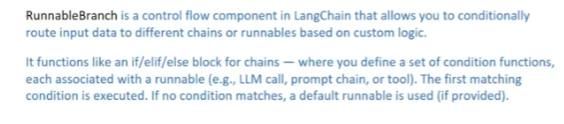

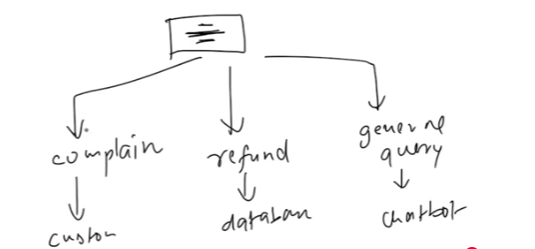

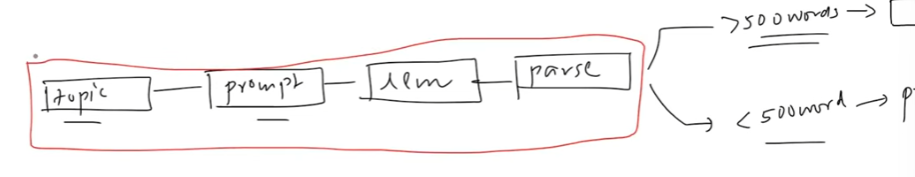

In [23]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnableLambda

load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

prompt1 = PromptTemplate(
    template = "write a detailed report on {topic}",
    input_variables = ['topic']
)

prompt2 = PromptTemplate(
    template= "Summarize the following report in 3 lines: {report}",
    input_variables = ['report']
)

parser = StrOutputParser()

reportGenChain = RunnableSequence(prompt1, model, parser)

# if deatailed report is  greater tha 500 words then summerize if not keep it as it is
brainChain = RunnableBranch(
    (lambda x: len(x.split()) > 500, RunnableSequence(prompt2, model, parser)),
    RunnablePassthrough()
)

finalChain = RunnableSequence(reportGenChain, brainChain)
result = finalChain.invoke({'topic': 'Artificial Intelligence'})
print(result)




**Artificial Intelligence (AI) Report**

**Executive Summary**

Artificial Intelligence (AI) has become a crucial aspect of modern life, transforming the way we live, work, and interact with each other. This report provides a comprehensive overview of the current state of AI, its applications, benefits, challenges, and future prospects.

**Introduction**

Artificial Intelligence refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, and perception. AI systems use algorithms and data to simulate human intelligence and behavior, enabling them to learn from experience, adapt to new situations, and improve their performance over time.

**Types of Artificial Intelligence**

There are several types of AI, including:

1. **Narrow or Weak AI**: Designed to perform a specific task, such as playing chess, recognizing faces, or translating languages.
2. **General or Strong AI**: Aims to si

In [24]:
finalChain.get_graph().print_ascii()

  +-------------+    
  | PromptInput |    
  +-------------+    
          *          
          *          
          *          
+----------------+   
| PromptTemplate |   
+----------------+   
          *          
          *          
          *          
+-----------------+  
| ChatHuggingFace |  
+-----------------+  
          *          
          *          
          *          
+-----------------+  
| StrOutputParser |  
+-----------------+  
          *          
          *          
          *          
    +--------+       
    | Branch |       
    +--------+       
          *          
          *          
          *          
  +--------------+   
  | BranchOutput |   
  +--------------+   


# LCEL : LangChain Expression Language 

U can write the runnableSequence using pipe '|'